# Visualization of Drone Dataset with Helios Simulated Images

This notebook visualizes:
1. **Original drone orthophoto** - High-resolution RGB imagery from drone (cropped to plot extent)
2. **All plot boundaries** from GeoJSON - Geographic boundaries of experimental plots
3. **Optional: Single plot analysis** - Grid of 14 columns x 40 rows (560 images per plot)
4. **Georeferenced comparison** - Simulated images placed at their geographic locations

## Workflow:
- Load drone orthophoto and plot boundaries
- Show all plots (cropped to their geographic extent)
- **Optional**: Focus on a specific plot to see detailed grid analysis
  - Extract specific plot region  
  - Load all Helios-generated images for the plot (14x40 grid)
  - Create composite image from grid tiles
  - Georeference composite to match plot geographic extent
  - Compare original vs simulated side-by-side

## Configuration:
- Set `focus_plot = None` to visualize all plots without needing to specify row/column
- Set `focus_plot = (column, row)` to analyze a specific plot in detail with grid visualization

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from pathlib import Path
from PIL import Image

import rasterio
from rasterio.mask import mask
from rasterio.plot import show
import geopandas as gpd
from shapely.geometry import box, mapping
from rasterio.windows import Window
from rasterio.transform import from_bounds

## Configuration

Set paths to drone orthophoto, GeoJSON plot boundaries, and Helios output directory.

In [2]:
# Paths configuration
ortho_path = "/home/lion397/GEMINI/heesup/dataset/2025_Davis/2025-06-06/Drone/2025-06-06-RGB.tif"
geojson_path = "/home/lion397/GEMINI/heesup/dataset/2025_Davis/Plot-Boundary-WGS84.geojson"
helios_output_dir = "/home/lion397/GEMINI/heesup/dataset/2025_Davis/HELIOS/"

# DAP to visualize
dap = 10

# Optional: Specify a single plot to focus on (set to None to visualize all plots)
# Format: (column, row) based on GeoJSON properties
focus_plot = None  # Set to (10, 10) to focus on a specific plot, or None to show all
# focus_plot = (10, 10)  # Example: column 10, row 10

print(f"Configuration:")
print(f"  Drone orthophoto: {ortho_path}")
print(f"  Plot boundaries: {geojson_path}")
print(f"  Helios output: {helios_output_dir}")
print(f"  Target DAP: {dap}")
if focus_plot:
    print(f"  Focus on plot: Column {focus_plot[0]}, Row {focus_plot[1]}")
else:
    print(f"  Visualizing all plots")

Configuration:
  Drone orthophoto: /home/lion397/GEMINI/heesup/dataset/2025_Davis/2025-06-06/Drone/2025-06-06-RGB.tif
  Plot boundaries: /home/lion397/GEMINI/heesup/dataset/2025_Davis/Plot-Boundary-WGS84.geojson
  Helios output: /home/lion397/GEMINI/heesup/dataset/2025_Davis/HELIOS/
  Target DAP: 10
  Visualizing all plots


## Step 1: Load and Visualize Original Drone Image with All Plot Boundaries

In [3]:
# Load the GeoJSON with plot boundaries
gdf = gpd.read_file(geojson_path)
print(f"Loaded {len(gdf)} plots from GeoJSON")
print(f"CRS: {gdf.crs}")
print(f"Columns: {gdf.columns.tolist()}")
print(f"\nFirst few rows:")
print(gdf.head())

Loaded 560 plots from GeoJSON
CRS: EPSG:4326
Columns: ['row', 'column', 'plot', 'Plot', 'year', 'location', 'population', 'accession', 'geometry']

First few rows:
   row  column plot Plot  year location population accession  \
0    1       1  1_1  1_1  None     None       None      None   
1    1       2  1_2  1_2  None     None       None      None   
2    1       3  1_3  1_3  None     None       None      None   
3    1       4  1_4  1_4  None     None       None      None   
4    1       5  1_5  1_5  None     None       None      None   

                                            geometry  
0  POLYGON ((-121.77759 38.53638, -121.7776 38.53...  
1  POLYGON ((-121.7776 38.53638, -121.77762 38.53...  
2  POLYGON ((-121.77762 38.53638, -121.77764 38.5...  
3  POLYGON ((-121.77764 38.53638, -121.77765 38.5...  
4  POLYGON ((-121.77766 38.53638, -121.77767 38.5...  


In [4]:
# Load the drone orthophoto
with rasterio.open(ortho_path) as src:
    ortho_crs = src.crs
    ortho_bounds = src.bounds
    ortho_transform = src.transform
    ortho_shape = (src.height, src.width)
    
    print(f"Ortho CRS: {ortho_crs}")
    print(f"Ortho bounds: {ortho_bounds}")
    print(f"Ortho shape: {ortho_shape}")
    print(f"Ortho resolution: {src.res}")
    
    # Reproject GeoJSON to match ortho CRS if needed
    if gdf.crs != ortho_crs:
        print(f"Reprojecting GeoJSON from {gdf.crs} to {ortho_crs}")
        gdf = gdf.to_crs(ortho_crs)
    
    # Read a downsampled version for overview (every 10th pixel)
    ortho_overview = src.read([1, 2, 3], out_shape=(3, src.height // 10, src.width // 10))
    ortho_overview = np.moveaxis(ortho_overview, 0, -1)  # Move channels to last dimension

Ortho CRS: EPSG:4326
Ortho bounds: BoundingBox(left=-121.778848025059, bottom=38.53625643011083, right=-121.77751917560244, top=38.5370246309701)
Ortho shape: (12318, 16736)
Ortho resolution: (7.940066064591118e-08, 6.236408989036703e-08)
Reprojecting GeoJSON from EPSG:4326 to EPSG:4326


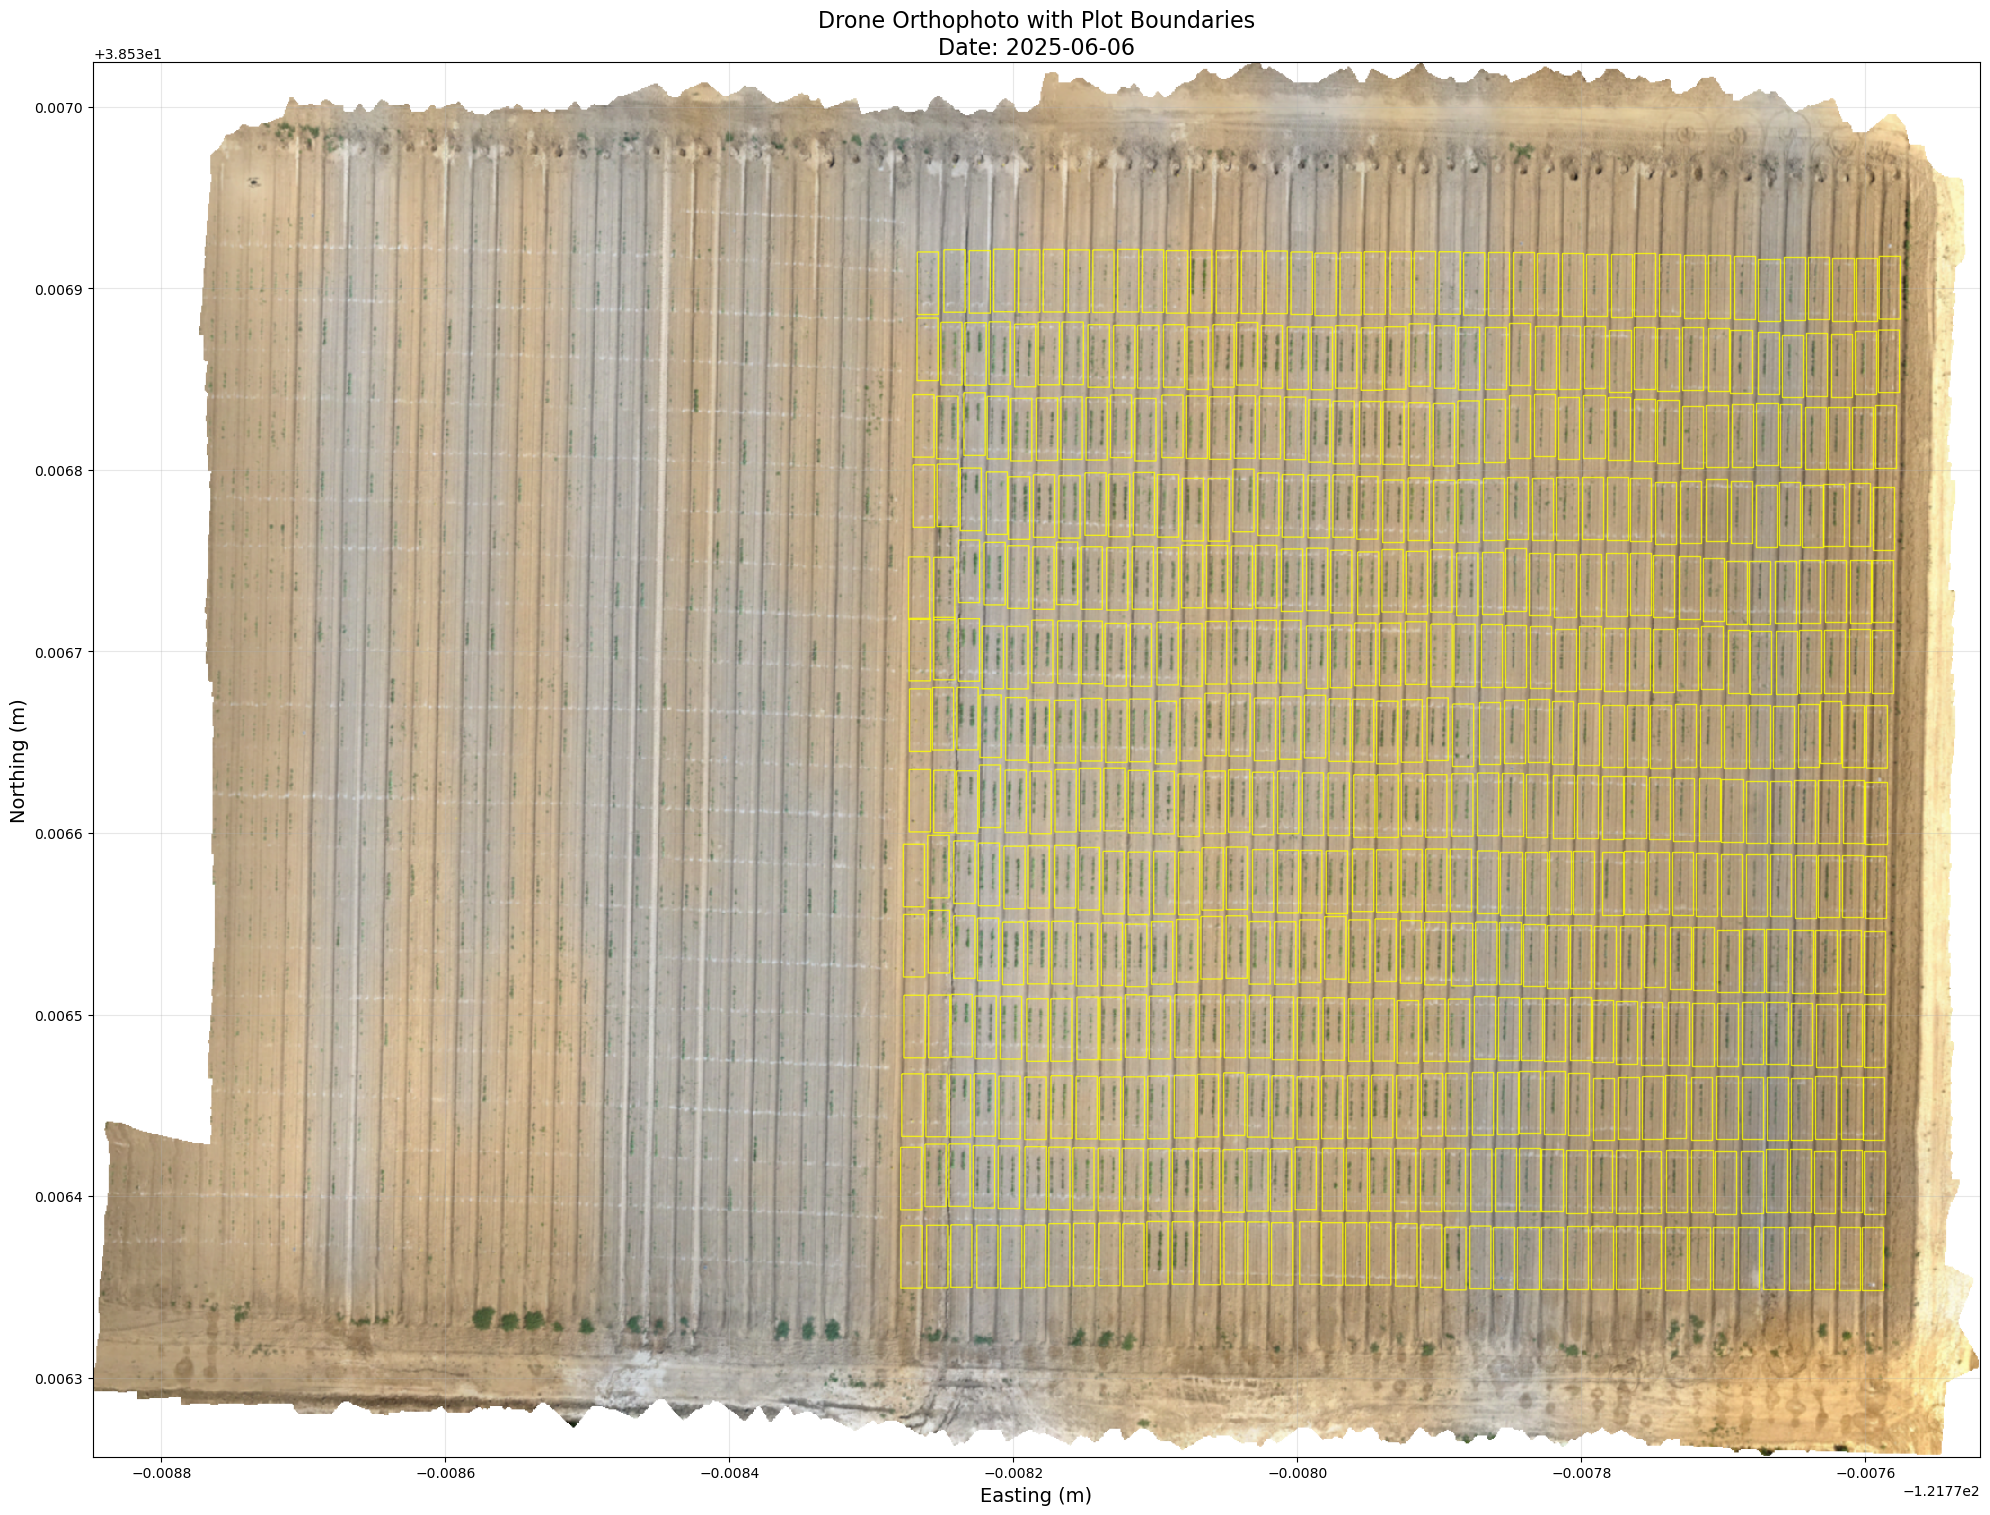


Total plots: 560
Plot extent: [-121.77827927   38.53634831 -121.77757522   38.53692161]


In [14]:
# Visualize the full drone image with all plot boundaries
fig, ax = plt.subplots(figsize=(20, 16))

# Display the downsampled orthophoto
ax.imshow(ortho_overview, extent=[ortho_bounds.left, ortho_bounds.right, ortho_bounds.bottom, ortho_bounds.top], aspect='auto')

# Draw all plot boundaries
gdf.boundary.plot(ax=ax, color='yellow', linewidth=1, alpha=0.8)

# Highlight a specific plot if focus_plot is set
if focus_plot:
    example_col, example_row = focus_plot
    example_plot = gdf[(gdf['column'] == example_col) & (gdf['row'] == example_row)]
    if len(example_plot) > 0:
        example_plot.boundary.plot(ax=ax, color='red', linewidth=3, label=f'Plot Column {example_col}, Row {example_row}')
        ax.legend(fontsize=14)
    title_suffix = f", Highlighted: Column {example_col}, Row {example_row}"
else:
    title_suffix = ""

ax.set_title(f'Drone Orthophoto with Plot Boundaries\nDate: 2025-06-06{title_suffix}', 
             fontsize=16)
ax.set_xlabel('Easting (m)', fontsize=14)
ax.set_ylabel('Northing (m)', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTotal plots: {len(gdf)}")
plots_bounds = gdf.total_bounds
print(f"Plot extent: {plots_bounds}")

## Step 2: Extract and Visualize Specific Plot Region

In [15]:
# Extract plot region from drone orthophoto
if focus_plot:
    example_col, example_row = focus_plot
    example_plot = gdf[(gdf['column'] == example_col) & (gdf['row'] == example_row)]
    
    if len(example_plot) == 0:
        print(f"Error: Plot with Column={example_col}, Row={example_row} not found!")
        print(f"Available columns: {sorted(gdf['column'].unique())}")
        print(f"Available rows: {sorted(gdf['row'].unique())}")
    else:
        plot_geom = example_plot.geometry.iloc[0]
        plot_bounds_list = [mapping(plot_geom)]
        
        with rasterio.open(ortho_path) as src:
            # Mask the orthophoto to the plot boundary
            plot_image, plot_transform = mask(src, plot_bounds_list, crop=True, filled=False)
            plot_image = np.moveaxis(plot_image[0:3], 0, -1)  # Take RGB channels and move to last dimension
            
            # Get plot metadata
            plot_meta = src.meta.copy()
            plot_meta.update({
                "height": plot_image.shape[0],
                "width": plot_image.shape[1],
                "transform": plot_transform
            })
            
            print(f"Plot image shape: {plot_image.shape}")
            print(f"Plot bounds: {example_plot.total_bounds}")
            
            # Store for later use
            plot_ortho_image = plot_image
            plot_ortho_transform = plot_transform
            plot_ortho_bounds = example_plot.total_bounds  # [minx, miny, maxx, maxy]
else:
    print("No specific plot selected. Skipping individual plot extraction.")
    print("Set focus_plot = (column, row) in the configuration to extract a specific plot.")

No specific plot selected. Skipping individual plot extraction.
Set focus_plot = (column, row) in the configuration to extract a specific plot.


In [16]:
# Visualize the extracted plot region (only if focus_plot is set)
if focus_plot and 'plot_ortho_image' in locals():
    fig, ax = plt.subplots(figsize=(12, 10))

    extent = [plot_ortho_bounds[0], plot_ortho_bounds[2], plot_ortho_bounds[1], plot_ortho_bounds[3]]
    ax.imshow(plot_ortho_image, extent=extent, aspect='auto')

    # Draw plot boundary
    example_plot.boundary.plot(ax=ax, color='yellow', linewidth=2)

    ax.set_title(f'Extracted Plot Region - Column {example_col}, Row {example_row}\nDrone Image (2025-06-06)', 
                 fontsize=14)
    ax.set_xlabel('Easting (m)', fontsize=12)
    ax.set_ylabel('Northing (m)', fontsize=12)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Skipping plot extraction visualization (no focus_plot specified)")

Skipping plot extraction visualization (no focus_plot specified)


## Step 3: Load and Georeference DAP 10 Helios Simulated Image

In [17]:
# Find the Helios simulated image for specific plot at DAP 10 (only if focus_plot is set)
if focus_plot:
    example_col, example_row = focus_plot
    # Note: File naming might use 'bed' for column - adjust pattern if needed
    helios_image_name = f"dap_{dap}_plot_{example_col}_{example_row}_0000.jpeg"
    helios_image_path = os.path.join(helios_output_dir, helios_image_name)

    helios_params_name = f"dap_{dap}_plot_{example_col}_{example_row}_0000_params.json"
    helios_params_path = os.path.join(helios_output_dir, helios_params_name)

    # Check if files exist
    if not os.path.exists(helios_image_path):
        print(f"Error: Helios image not found: {helios_image_path}")
        print(f"Available DAP {dap} files:")
        import glob
        available_files = glob.glob(os.path.join(helios_output_dir, f"dap_{dap}_plot_*.jpeg"))
        for f in available_files[:10]:
            print(f"  {os.path.basename(f)}")
    else:
        print(f"Found Helios image: {helios_image_path}")
        
    if os.path.exists(helios_params_path):
        print(f"Found Helios params: {helios_params_path}")
        
        # Load params to get plot information
        with open(helios_params_path, 'r') as f:
            helios_params = json.load(f)
        
        # Display some params info
        print(f"\nHelios Parameters:")
        print(f"  Camera height: {helios_params.get('cameraproperties', {}).get('camera_height', {})}")
        print(f"  Camera resolution: {helios_params.get('cameraproperties', {}).get('camera_resolution_x', {})['value']} x {helios_params.get('cameraproperties', {}).get('camera_resolution_y', {})['value']}")
        print(f"  Ground size: {helios_params.get('ground', {}).get('size_x', {})['value']:.2f} x {helios_params.get('ground', {}).get('size_y', {})['value']:.2f} m")
        print(f"  HFOV: {helios_params.get('cameraproperties', {}).get('HFOV', {})['value']:.2f}°")
    else:
        print(f"Warning: Helios params not found: {helios_params_path}")
else:
    print("Skipping individual plot Helios file search (no focus_plot specified)")

Skipping individual plot Helios file search (no focus_plot specified)


In [18]:
# Load the Helios simulated image (only if focus_plot is set)
if focus_plot and 'helios_image_path' in locals() and os.path.exists(helios_image_path):
    helios_image = Image.open(helios_image_path)
    helios_image_array = np.array(helios_image)
    
    print(f"Helios image shape: {helios_image_array.shape}")
    print(f"Helios image size: {helios_image.size}")
    
    # Display the raw Helios image
    fig, ax = plt.subplots(figsize=(12, 10))
    ax.imshow(helios_image_array)
    ax.set_title(f'Helios Simulated Image - DAP {dap}\nPlot Column {example_col}, Row {example_row}', fontsize=14)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    if focus_plot:
        print("Skipping - Helios image not found")
    else:
        print("Skipping single image visualization (no focus_plot specified)")

Skipping single image visualization (no focus_plot specified)


## Step 4: Visualize DAP 10 Images in Grid Layout (14 columns x 40 rows)

Load all 560 Helios images for the plot and place them in their geographic positions to compare with original drone image.

In [19]:
import glob

# Only run grid visualization if focus_plot is specified
if not focus_plot:
    print("Skipping grid visualization - no focus_plot specified")
    print("Set focus_plot = (column, row) in configuration to visualize grid for a specific plot")
else:
    example_col, example_row = focus_plot
    
    # Grid configuration (modify based on your actual grid setup)
    NUM_COLS = 14  # Number of columns in the grid
    NUM_ROWS = 40  # Number of rows in the grid

    # Find all DAP 10 images for this plot
    # Pattern assumes naming like: dap_10_plot_COL_ROW_*.jpeg
    # Adjust pattern based on actual naming convention
    image_pattern = os.path.join(helios_output_dir, f"dap_{dap}_plot_{example_col}_{example_row}_*.jpeg")
    helios_images = sorted(glob.glob(image_pattern))

    print(f"Found {len(helios_images)} Helios images for plot column {example_col}, row {example_row}")
    print(f"Expected: {NUM_COLS * NUM_ROWS} images")

    if len(helios_images) == 0:
        print(f"\nNo images found matching pattern: {image_pattern}")
        print("\nLooking for any DAP 10 images...")
        all_dap10 = glob.glob(os.path.join(helios_output_dir, f"dap_{dap}_*.jpeg"))
        print(f"Found {len(all_dap10)} total DAP {dap} images")
        if len(all_dap10) > 0:
            print("Sample filenames:")
            for f in all_dap10[:5]:
                print(f"  {os.path.basename(f)}")
    else:
        print("\nSample filenames:")
        for f in helios_images[:5]:
            print(f"  {os.path.basename(f)}")
        
        # Create a composite image from all grid images
        if len(helios_images) == NUM_COLS * NUM_ROWS:
            # Load first image to get dimensions
            first_img = Image.open(helios_images[0])
            tile_width, tile_height = first_img.size
            
            # Create a large canvas for all tiles
            grid_width = NUM_COLS * tile_width
            grid_height = NUM_ROWS * tile_height
            composite = np.zeros((grid_height, grid_width, 3), dtype=np.uint8)
            
            print(f"\nCreating composite image: {grid_width} x {grid_height} px")
            print(f"Tile size: {tile_width} x {tile_height} px")
            
            # Place each image in its grid position
            for idx, img_path in enumerate(helios_images):
                img = Image.open(img_path)
                img_array = np.array(img)
                
                # Calculate grid position (assuming row-major order: 0,0 -> 0,1 -> ... -> 0,13 -> 1,0 ...)
                row = idx // NUM_COLS
                col = idx % NUM_COLS
                
                # Place image in composite
                y_start = row * tile_height
                y_end = y_start + tile_height
                x_start = col * tile_width
                x_end = x_start + tile_width
                
                composite[y_start:y_end, x_start:x_end] = img_array
            
            # Now georeference the composite image to the plot bounds
            if 'plot_ortho_image' in locals():
                fig, axes = plt.subplots(1, 3, figsize=(24, 8))
                
                # Panel 1: Original drone image with plot boundary
                ax1 = axes[0]
                extent = [plot_ortho_bounds[0], plot_ortho_bounds[2], plot_ortho_bounds[1], plot_ortho_bounds[3]]
                ax1.imshow(plot_ortho_image, extent=extent, aspect='auto')
                example_plot.boundary.plot(ax=ax1, color='yellow', linewidth=2)
                ax1.set_title(f'Original Drone Image\nColumn {example_col}, Row {example_row}\n(2025-06-06)', fontsize=12)
                ax1.set_xlabel('Easting (m)', fontsize=10)
                ax1.set_ylabel('Northing (m)', fontsize=10)
                ax1.grid(True, alpha=0.3)
                
                # Panel 2: Composite Helios image (raw, showing grid structure)
                ax2 = axes[1]
                ax2.imshow(composite)
                ax2.set_title(f'Helios Grid Composite\nDAP {dap} ({NUM_COLS}x{NUM_ROWS} tiles)', fontsize=12)
                ax2.set_xlabel(f'Pixels (x={grid_width})', fontsize=10)
                ax2.set_ylabel(f'Pixels (y={grid_height})', fontsize=10)
                
                # Draw grid lines to show individual tiles
                for i in range(1, NUM_COLS):
                    ax2.axvline(i * tile_width, color='white', alpha=0.3, linewidth=0.5)
                for i in range(1, NUM_ROWS):
                    ax2.axhline(i * tile_height, color='white', alpha=0.3, linewidth=0.5)
                
                # Panel 3: Georeferenced overlay
                ax3 = axes[2]
                # Show drone image at reduced opacity
                ax3.imshow(plot_ortho_image, extent=extent, aspect='auto', alpha=0.3)
                
                # Overlay the composite Helios image with plot boundary extent
                ax3.imshow(composite, extent=extent, aspect='auto', alpha=0.7)
                
                # Draw plot boundary
                example_plot.boundary.plot(ax=ax3, color='red', linewidth=2, linestyle='--', label='Plot Boundary')
                
                ax3.set_title(f'Georeferenced Overlay\nHelios Grid (DAP {dap}) on Drone Image', fontsize=12)
                ax3.set_xlabel('Easting (m)', fontsize=10)
                ax3.set_ylabel('Northing (m)', fontsize=10)
                ax3.legend(fontsize=10)
                ax3.grid(True, alpha=0.3)
                
                plt.tight_layout()
                plt.show()
                
                print(f"\nSuccessfully created and georeferenced composite image")
            else:
                print("Cannot create comparison - plot_ortho_image not available")
        else:
            print(f"\nWarning: Expected {NUM_COLS * NUM_ROWS} images but found {len(helios_images)}")
            print("Cannot create composite. Please check image naming pattern.")

Skipping grid visualization - no focus_plot specified
Set focus_plot = (column, row) in configuration to visualize grid for a specific plot


## Step 6: Compare Multiple Plots

## Step 5: Visualize Individual Grid Tiles on Empty Map

Visualize the grid tiles placed at their geographic locations on a blank canvas to see the spatial distribution.

In [20]:
# Visualize each grid tile at its geographic location on a blank map
if focus_plot and 'helios_images' in locals() and len(helios_images) > 0 and len(helios_images) == NUM_COLS * NUM_ROWS:
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    # Calculate the geographic extent of each grid cell
    plot_width_m = plot_ortho_bounds[2] - plot_ortho_bounds[0]
    plot_height_m = plot_ortho_bounds[3] - plot_ortho_bounds[1]
    
    cell_width_m = plot_width_m / NUM_COLS
    cell_height_m = plot_height_m / NUM_ROWS
    
    print(f"Plot dimensions: {plot_width_m:.2f}m x {plot_height_m:.2f}m")
    print(f"Cell dimensions: {cell_width_m:.3f}m x {cell_height_m:.3f}m")
    
    # Panel 1: Original drone with grid overlay showing cell boundaries
    ax1 = axes[0]
    extent = [plot_ortho_bounds[0], plot_ortho_bounds[2], plot_ortho_bounds[1], plot_ortho_bounds[3]]
    ax1.imshow(plot_ortho_image, extent=extent, aspect='auto', alpha=0.7)
    
    # Draw grid cells
    for row in range(NUM_ROWS + 1):
        y = plot_ortho_bounds[1] + row * cell_height_m
        ax1.axhline(y, color='yellow', alpha=0.5, linewidth=0.5)
    
    for col in range(NUM_COLS + 1):
        x = plot_ortho_bounds[0] + col * cell_width_m
        ax1.axvline(x, color='yellow', alpha=0.5, linewidth=0.5)
    
    example_plot.boundary.plot(ax=ax1, color='red', linewidth=2)
    ax1.set_title(f'Original Drone with {NUM_COLS}x{NUM_ROWS} Grid\nColumn {example_col}, Row {example_row}', fontsize=12)
    ax1.set_xlabel('Easting (m)', fontsize=10)
    ax1.set_ylabel('Northing (m)', fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Panel 2: Helios tiles placed on blank canvas at their geographic locations
    ax2 = axes[1]
    
    # Set up blank canvas with same geographic extent
    ax2.set_xlim(plot_ortho_bounds[0], plot_ortho_bounds[2])
    ax2.set_ylim(plot_ortho_bounds[1], plot_ortho_bounds[3])
    ax2.set_aspect('equal')
    
    # Place each Helios tile at its geographic location
    for idx, img_path in enumerate(helios_images):
        img = Image.open(img_path)
        img_array = np.array(img)
        
        # Calculate grid position
        row = idx // NUM_COLS
        col = idx % NUM_COLS
        
        # Calculate geographic extent for this cell
        x_min = plot_ortho_bounds[0] + col * cell_width_m
        x_max = x_min + cell_width_m
        y_min = plot_ortho_bounds[1] + row * cell_height_m
        y_max = y_min + cell_height_m
        
        # Plot the image at its location
        ax2.imshow(img_array, extent=[x_min, x_max, y_min, y_max], aspect='auto', alpha=0.9)
    
    # Draw plot boundary
    example_plot.boundary.plot(ax=ax2, color='red', linewidth=2, label='Plot Boundary')
    
    # Draw grid lines
    for row in range(NUM_ROWS + 1):
        y = plot_ortho_bounds[1] + row * cell_height_m
        ax2.axhline(y, color='white', alpha=0.3, linewidth=0.5)
    
    for col in range(NUM_COLS + 1):
        x = plot_ortho_bounds[0] + col * cell_width_m
        ax2.axvline(x, color='white', alpha=0.3, linewidth=0.5)
    
    ax2.set_title(f'Helios Tiles on Empty Canvas\nDAP {dap} ({NUM_COLS}x{NUM_ROWS} grid)', fontsize=12)
    ax2.set_xlabel('Easting (m)', fontsize=10)
    ax2.set_ylabel('Northing (m)', fontsize=10)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Not enough images to create grid visualization or no focus_plot specified")

Not enough images to create grid visualization or no focus_plot specified


Found 560 DAP 10 images


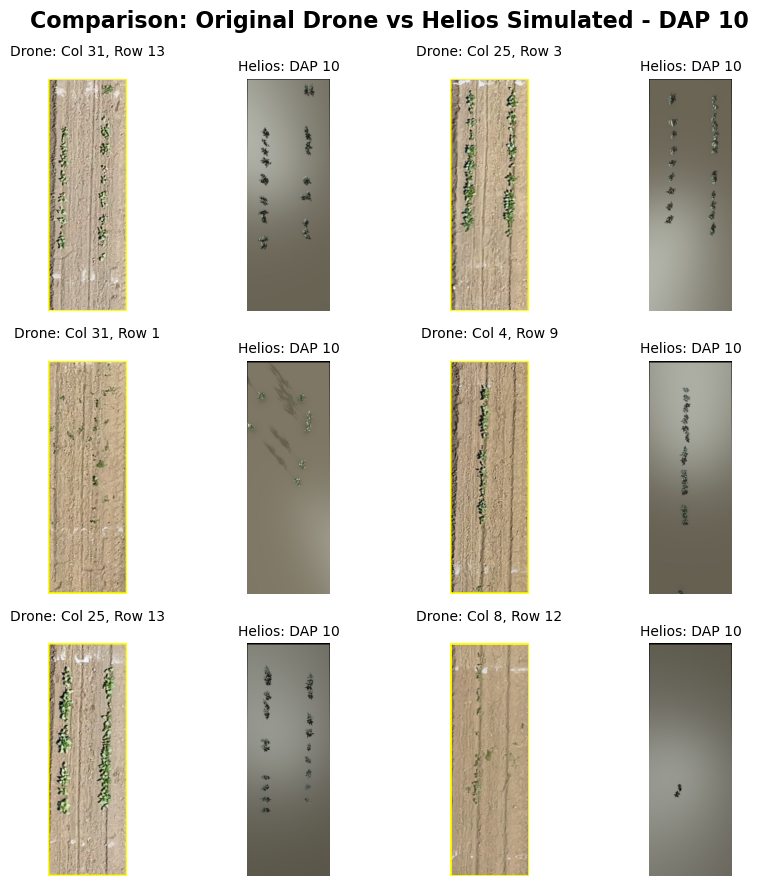

In [21]:
# Compare multiple plots side by side with original drone images
import glob

# Find all available DAP 10 images
dap10_images = glob.glob(os.path.join(helios_output_dir, f"dap_{dap}_plot_*_0000.jpeg"))
print(f"Found {len(dap10_images)} DAP {dap} images")

if len(dap10_images) == 0:
    print("No DAP images found to compare")
else:
    # Select a few random plots to visualize
    np.random.seed(42)
    sample_plots = np.random.choice(dap10_images, min(6, len(dap10_images)), replace=False)

    fig, axes = plt.subplots(3, 4, figsize=(9, 9))
    
    for idx, image_path in enumerate(sample_plots):
        if idx >= 6:
            break
        
        # Parse plot info from filename
        basename = os.path.basename(image_path)
        # Format: dap_10_plot_COL_ROW_0000.jpeg
        parts = basename.replace('.jpeg', '').split('_')
        col = int(parts[3])
        row = int(parts[4])
        
        # Get the plot from GeoDF
        plot_gdf = gdf[(gdf['column'] == col) & (gdf['row'] == row)]
        
        if len(plot_gdf) > 0:
            plot_geom = plot_gdf.geometry.iloc[0]
            plot_bounds_list = [mapping(plot_geom)]
            plot_bounds = plot_gdf.total_bounds
            
            # Extract drone orthophoto for this plot
            with rasterio.open(ortho_path) as src:
                plot_drone_image, _ = mask(src, plot_bounds_list, crop=True, filled=False)
                plot_drone_image = np.moveaxis(plot_drone_image[0:3], 0, -1)
            
            # Load Helios image
            helios_img = Image.open(image_path)
            helios_array = np.array(helios_img)
            
            # Row for this plot (2 images per plot)
            plot_row = idx // 2
            col_offset = (idx % 2) * 2
            
            # Left: Original drone image
            ax_drone = axes[plot_row, col_offset]
            extent = [plot_bounds[0], plot_bounds[2], plot_bounds[1], plot_bounds[3]]
            ax_drone.imshow(plot_drone_image, extent=extent, aspect='auto')
            plot_gdf.boundary.plot(ax=ax_drone, color='yellow', linewidth=2)
            ax_drone.set_title(f'Drone: Col {col}, Row {row}', fontsize=10)
            ax_drone.axis('off')
            
            # Right: Helios simulated image
            ax_helios = axes[plot_row, col_offset + 1]
            ax_helios.imshow(helios_array)
            ax_helios.set_title(f'Helios: DAP {dap}', fontsize=10)
            ax_helios.axis('off')
        else:
            # If plot not found in GeoJSON, just show Helios image
            helios_img = Image.open(image_path)
            helios_array = np.array(helios_img)
            
            plot_row = idx // 2
            col_offset = (idx % 2) * 2
            
            ax_drone = axes[plot_row, col_offset]
            ax_drone.text(0.5, 0.5, f'Plot {col}-{row}\nNot in GeoJSON', 
                         ha='center', va='center', fontsize=10)
            ax_drone.axis('off')
            
            ax_helios = axes[plot_row, col_offset + 1]
            ax_helios.imshow(helios_array)
            ax_helios.set_title(f'Helios: Col {col}, Row {row}\nDAP {dap}', fontsize=10)
            ax_helios.axis('off')

    # Hide unused subplots
    for idx in range(len(sample_plots) * 2, 12):
        axes[idx // 4, idx % 4].axis('off')

    plt.suptitle(f'Comparison: Original Drone vs Helios Simulated - DAP {dap}', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Step 7: Side-by-Side Comparison - Original vs Simulated

Creating summary visualization for all plots...
Found 560 Helios-generated plots for DAP 10

Creating overlay of Helios images on drone orthophoto...
Ortho overview size: 1673 x 1231 pixels
Resolution: 1258983.85 px/m (X), 1602445.49 px/m (Y)
Processing 560 Helios images...


100%|██████████| 560/560 [00:06<00:00, 84.71it/s]


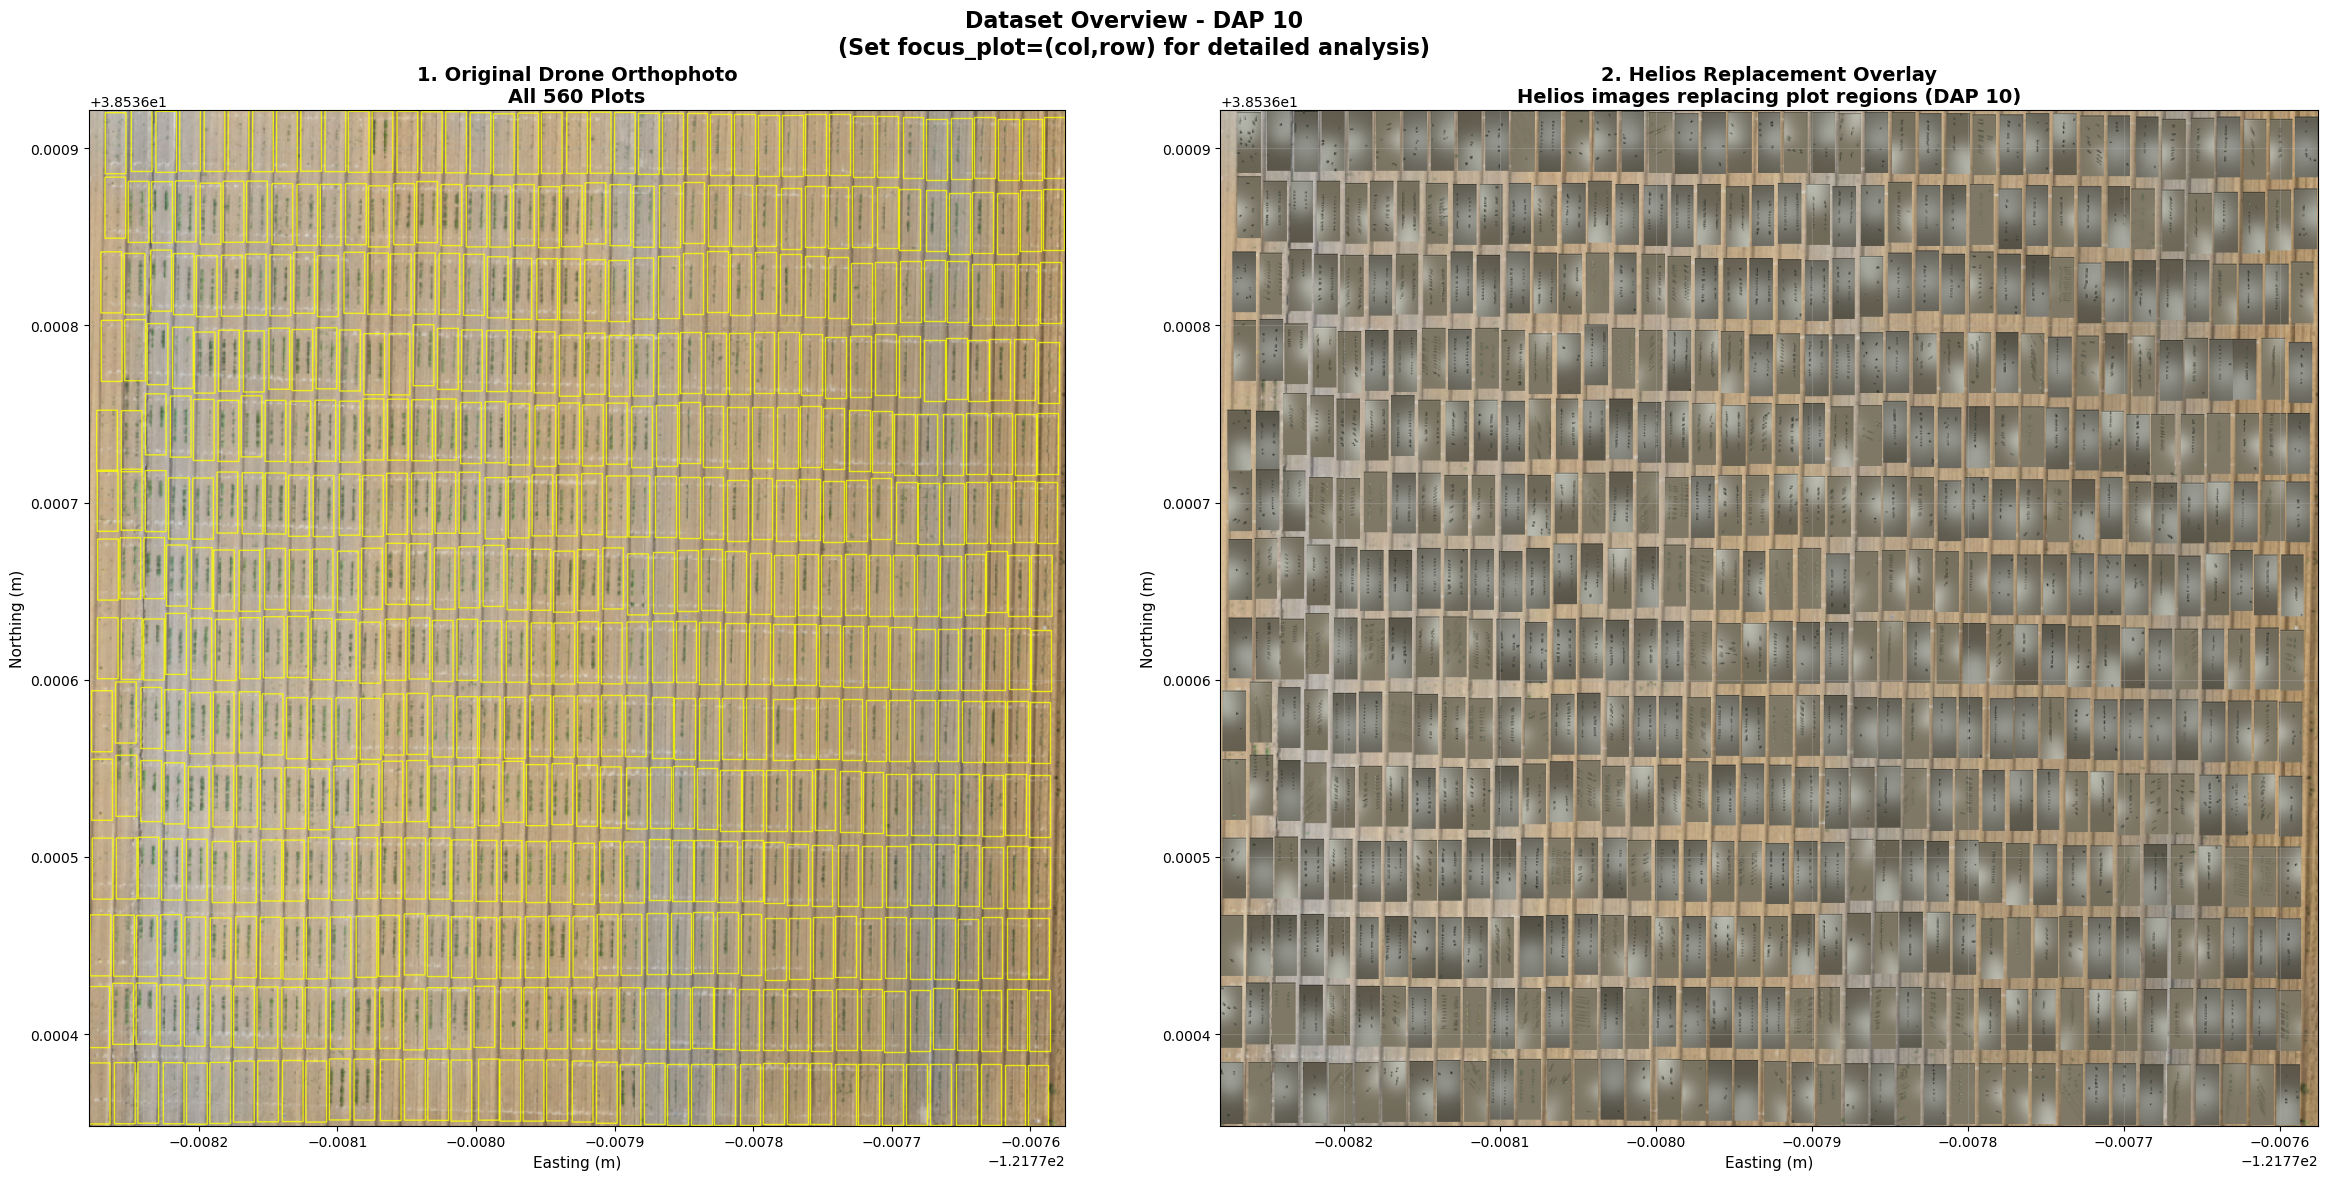

In [29]:
from tqdm import tqdm
# Final comprehensive comparison
# This works with or without focus_plot

if focus_plot:
    # Detailed grid visualization for specific plot
    if 'helios_images' in locals() and len(helios_images) > 0 and len(helios_images) == NUM_COLS * NUM_ROWS:
        # Load first image to get dimensions
        first_img = Image.open(helios_images[0])
        tile_width, tile_height = first_img.size
        
        # Create composite
        grid_width = NUM_COLS * tile_width
        grid_height = NUM_ROWS * tile_height
        composite = np.zeros((grid_height, grid_width, 3), dtype=np.uint8)
        
        for idx, img_path in enumerate(helios_images):
            img = Image.open(img_path)
            img_array = np.array(img)
            row = idx // NUM_COLS
            col = idx % NUM_COLS
            y_start = row * tile_height
            y_end = y_start + tile_height
            x_start = col * tile_width
            x_end = x_start + tile_width
            composite[y_start:y_end, x_start:x_end] = img_array
        
        # Create final comparison figure
        fig = plt.figure(figsize=(24, 10))
        
        # Panel 1: Original Drone Orthophoto
        ax1 = plt.subplot(1, 3, 1)
        extent = [plot_ortho_bounds[0], plot_ortho_bounds[2], plot_ortho_bounds[1], plot_ortho_bounds[3]]
        ax1.imshow(plot_ortho_image, extent=extent, aspect='auto')
        example_plot.boundary.plot(ax=ax1, color='yellow', linewidth=3, label='Plot Boundary')
        ax1.set_title(f'1. Original Drone Image\n(2025-06-06)\nColumn {example_col}, Row {example_row}', 
                      fontsize=14, fontweight='bold')
        ax1.set_xlabel('Easting (m)', fontsize=11)
        ax1.set_ylabel('Northing (m)', fontsize=11)
        ax1.legend(fontsize=10)
        ax1.grid(True, alpha=0.3)
        
        # Panel 2: Georeferenced Helios Simulation
        ax2 = plt.subplot(1, 3, 2)
        ax2.imshow(composite, extent=extent, aspect='auto')
        example_plot.boundary.plot(ax=ax2, color='red', linewidth=3, label='Plot Boundary')
        ax2.set_title(f'2. Helios Simulation (Georeferenced)\nDAP {dap} ({NUM_COLS}x{NUM_ROWS} grid)', 
                      fontsize=14, fontweight='bold')
        ax2.set_xlabel('Easting (m)', fontsize=11)
        ax2.set_ylabel('Northing (m)', fontsize=11)
        ax2.legend(fontsize=10)
        ax2.grid(True, alpha=0.3)
        
        # Panel 3: Blended Overlay
        ax3 = plt.subplot(1, 3, 3)
        ax3.imshow(plot_ortho_image, extent=extent, aspect='auto', alpha=0.5)
        ax3.imshow(composite, extent=extent, aspect='auto', alpha=0.5)
        example_plot.boundary.plot(ax=ax3, color='lime', linewidth=3, linestyle='--', label='Plot Boundary')
        ax3.set_title(f'3. Overlay Comparison\n(Original 50% + Simulated 50%)', 
                      fontsize=14, fontweight='bold')
        ax3.set_xlabel('Easting (m)', fontsize=11)
        ax3.set_ylabel('Northing (m)', fontsize=11)
        ax3.legend(fontsize=10)
        ax3.grid(True, alpha=0.3)
        
        plt.suptitle(f'Complete Dataset Visualization: Column {example_col}, Row {example_row} - DAP {dap}', 
                     fontsize=16, fontweight='bold', y=0.98)
        plt.tight_layout()
        plt.show()
        
        # Print summary statistics
        print("\n" + "="*60)
        print("VISUALIZATION SUMMARY")
        print("="*60)
        print(f"Plot: Column {example_col}, Row {example_row}")
        print(f"DAP: {dap}")
        print(f"Grid: {NUM_COLS} columns x {NUM_ROWS} rows = {NUM_COLS * NUM_ROWS} images")
        print(f"Tile size: {tile_width} x {tile_height} pixels")
        print(f"Composite size: {grid_width} x {grid_height} pixels")
        print(f"Geographic extent:")
        print(f"  X: {plot_ortho_bounds[0]:.2f} to {plot_ortho_bounds[2]:.2f} m (width: {plot_ortho_bounds[2]-plot_ortho_bounds[0]:.2f} m)")
        print(f"  Y: {plot_ortho_bounds[1]:.2f} to {plot_ortho_bounds[3]:.2f} m (height: {plot_ortho_bounds[3]-plot_ortho_bounds[1]:.2f} m)")
        print("="*60)
    else:
        print("Cannot create grid comparison - insufficient grid images found")
        print("Check that the Helios output directory contains the expected 560 images for this plot")
else:
    # Summary visualization for all plots (when focus_plot is None)
    print("Creating summary visualization for all plots...")
    
    # Define margin for plot display
    margin = 0  # meters
    
    # Find some sample DAP images to create an overview
    dap_sample_images = glob.glob(os.path.join(helios_output_dir, f"dap_{dap}_plot_*_0000.jpeg"))
    
    if len(dap_sample_images) == 0:
        print(f"No Helios images found in {helios_output_dir}")
        print("Please ensure Helios simulation has been run and images are saved to this directory")
    else:
        print(f"Found {len(dap_sample_images)} Helios-generated plots for DAP {dap}")
        
        # Create a comprehensive overview map showing all plots
        fig, axes = plt.subplots(1, 2, figsize=(24, 12))
        
        # Panel 1: Original drone with all plot boundaries
        ax1 = axes[0]
        ax1.imshow(ortho_overview, extent=[ortho_bounds.left, ortho_bounds.right, ortho_bounds.bottom, ortho_bounds.top], aspect='auto')
        ax1.set_xlim(plots_bounds[0], plots_bounds[2])
        ax1.set_ylim(plots_bounds[1], plots_bounds[3])
        gdf.boundary.plot(ax=ax1, color='yellow', linewidth=1, alpha=0.8)
        ax1.set_title(f'1. Original Drone Orthophoto\nAll {len(gdf)} Plots', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Easting (m)', fontsize=11)
        ax1.set_ylabel('Northing (m)', fontsize=11)
        ax1.grid(True, alpha=0.3)
        
        # Panel 2: Overlay Helios images on original orthophoto (fast method)
        print("\nCreating overlay of Helios images on drone orthophoto...")
        
        # Create a copy of ortho_overview for manipulation
        ortho_with_helios = ortho_overview.copy()
        
        # Get ortho dimensions and calculate scale factors
        ortho_height, ortho_width = ortho_overview.shape[:2]
        ortho_extent_width = ortho_bounds.right - ortho_bounds.left
        ortho_extent_height = ortho_bounds.top - ortho_bounds.bottom
        
        # Pixels per meter
        px_per_meter_x = ortho_width / ortho_extent_width
        px_per_meter_y = ortho_height / ortho_extent_height
        
        print(f"Ortho overview size: {ortho_width} x {ortho_height} pixels")
        print(f"Resolution: {px_per_meter_x:.2f} px/m (X), {px_per_meter_y:.2f} px/m (Y)")
        print(f"Processing {len(dap_sample_images)} Helios images...")
        
        # Replace plot regions with Helios images directly in memory
        for img_path in tqdm(dap_sample_images):
            basename = os.path.basename(img_path)
            parts = basename.replace('.jpeg', '').split('_')
            col = int(parts[3])
            row = int(parts[4])
            
            # Get the plot from GeoDF
            plot_gdf = gdf[(gdf['column'] == col) & (gdf['row'] == row)]
            
            if len(plot_gdf) > 0:
                plot_bounds = plot_gdf.total_bounds  # [minx, miny, maxx, maxy]
                
                # Convert geographic coordinates to pixel coordinates
                # Note: Image origin is top-left, geographic origin is bottom-left
                px_minx = int((plot_bounds[0] - ortho_bounds.left) * px_per_meter_x)
                px_maxx = int((plot_bounds[2] - ortho_bounds.left) * px_per_meter_x)
                px_miny = int((ortho_bounds.top - plot_bounds[3]) * px_per_meter_y)  # Flip Y
                px_maxy = int((ortho_bounds.top - plot_bounds[1]) * px_per_meter_y)  # Flip Y
                
                # Ensure within bounds
                px_minx = max(0, min(px_minx, ortho_width))
                px_maxx = max(0, min(px_maxx, ortho_width))
                px_miny = max(0, min(px_miny, ortho_height))
                px_maxy = max(0, min(px_maxy, ortho_height))
                
                # Calculate target size in pixels
                target_width = px_maxx - px_minx
                target_height = px_maxy - px_miny
                
                if target_width > 0 and target_height > 0:
                    # Load and resize Helios image to match pixel dimensions
                    helios_img = Image.open(img_path)
                    helios_resized = helios_img.resize((target_width, target_height), Image.LANCZOS)
                    helios_array = np.array(helios_resized)
                    
                    # Replace the region in ortho_with_helios
                    ortho_with_helios[px_miny:px_maxy, px_minx:px_maxx] = helios_array
        
        # Display the modified orthophoto
        ax2 = axes[1]
        ax2.imshow(ortho_with_helios, extent=[ortho_bounds.left, ortho_bounds.right, ortho_bounds.bottom, ortho_bounds.top], aspect='auto')
        ax2.set_xlim(plots_bounds[0], plots_bounds[2])
        ax2.set_ylim(plots_bounds[1], plots_bounds[3])
        
        # Draw all plot boundaries
        # gdf.boundary.plot(ax=ax2, color='lime', linewidth=1, alpha=0.8)
        
        ax2.set_title(f'2. Helios Replacement Overlay\nHelios images replacing plot regions (DAP {dap})', 
                     fontsize=14, fontweight='bold')
        ax2.set_xlabel('Easting (m)', fontsize=11)
        ax2.set_ylabel('Northing (m)', fontsize=11)
        ax2.grid(True, alpha=0.3)
        
        plt.suptitle(f'Dataset Overview - DAP {dap}\n(Set focus_plot=(col,row) for detailed analysis)', 
                    fontsize=16, fontweight='bold')

        plt.tight_layout()
        plt.show()


        # print(f"\nTo analyze a specific plot in detail, set: focus_plot = (column, row)")
        # print(f"For example: focus_plot = ({simulated_plots[0][0]}, {simulated_plots[0][1]})")
        

## Notes

### Grid Configuration
- The Helios simulation generates images in a **14 columns x 40 rows** grid layout for each plot
- Total of **560 images per plot per DAP**
- Each image represents a small tile of the plot

### Georeferencing Process
1. Load all 560 individual tiles
2. Arrange them in the correct grid order (row-major: 0,0 → 0,1 → ... → 39,13)
3. Create a composite image from all tiles
4. Map the composite to the plot's geographic extent (from GeoJSON boundary)
5. Overlay on original drone image for comparison

### File Naming Convention
Expected pattern: `dap_{DAP}_plot_{BED}_{ROW}_{GRID_INDEX}.jpeg`
- Adjust the `image_pattern` in Step 4 if your files use a different naming scheme

### Troubleshooting
- If no images are found, check the `helios_output_dir` path
- Verify the file naming pattern matches your Helios output
- Ensure DAP value matches your generated data
- Check that bed/row numbers exist in your dataset